In [1]:
import json, os, asyncio, pdb
import pandas as pd
from pathlib import Path
import pyprojroot, sys
from pyprojroot.criterion import has_file
sys.path.insert(0, str(pyprojroot.find_root(has_file("pyproject.toml"))))

from dotenv import load_dotenv

In [2]:
load_dotenv()
from kdutils.macro import base_path


In [3]:
def load_results(method, period):
    base_path1 = "/workspace/worker/pj/Chrono/cortex/sphiex/records"
    dir_path = Path(os.path.join(base_path1, "outofsam", method, str(period)))
    print(dir_path)
    snapshot_dict = {}
    for json_file in dir_path.glob("*.json"):
        date_str = json_file.stem.split("_")[0]
        with open(json_file, "r", encoding="utf-8") as f:
            snapshot = json.load(f)
            snapshot_dict[date_str] = snapshot
    return snapshot_dict


In [4]:
async def run(method, period, lookback=0):
    ticker = "000852"
    snapshot_dict = await asyncio.to_thread(load_results,
                                            method=method,
                                            period=period)
    res = []
    for k, v in snapshot_dict.items():
        predict_direction = v['trader_prediction']['predict_direction']
        if predict_direction == "UP":
            direction= 1
        elif predict_direction == "DOWN":
            direction = -1
        elif predict_direction == "FLAT":
            direction = 0
        confidence = v['trader_prediction']['confidence']
        forward_return = v['forward_return']
        res.append({
            'trade_date':k,
            'direction': direction,
            'confidence': confidence,
            'forward_return': forward_return / 3
        })
    results = pd.DataFrame(res).sort_values(by=['trade_date']).reset_index(drop=True)
    return results

In [5]:
method = 'train0'
period = 3

In [6]:
results = await run(method=method, period=period)

/workspace/worker/pj/Chrono/cortex/sphiex/records/outofsam/train0/3


In [7]:
results = results.set_index('trade_date')

In [8]:
### 不加置信度
results['no_confidence_returns'] = results['direction'] * results['forward_return']
results['confidence_returns'] = results['direction'] * results['confidence'] * results['forward_return']

In [9]:
results.tail()

,direction,confidence,forward_return,no_confidence_returns,confidence_returns
trade_date,,,,,
2026-08-07,0,0.50,-0.000777,-0.000000,-0.000000
2026-08-10,-1,0.58,0.003093,-0.003093,-0.001794
2026-08-11,0,0.55,0.007388,0.000000,0.000000
2026-08-12,-1,0.62,0.009794,-0.009794,-0.006072
2026-08-13,-1,0.62,-0.010993,0.010993,0.006815


<Axes: xlabel='trade_date'>

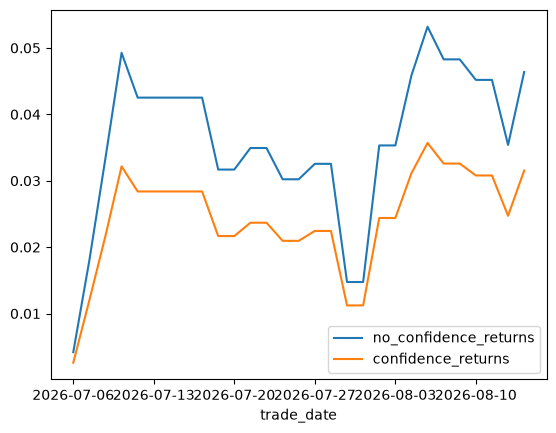

In [13]:
results[['no_confidence_returns','confidence_returns']].cumsum().plot()